### Q6(b) — Compute normalized 5×5 derivative-of-Gaussian kernels for σ=2

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------------
# Q6(b) - Derivative of Gaussian Kernels
# -----------------------------------

def gaussian(size, sigma):
    half = size // 2
    x, y = np.meshgrid(
        np.arange(-half, half + 1),
        np.arange(-half, half + 1)
    )
    g = (1 / (2 * np.pi * sigma**2)) * np.exp(-(x**2 + y**2) / (2 * sigma**2))
    return x, y, g

def dog_kernels(size, sigma):
    x, y, g = gaussian(size, sigma)

    gx = -(x / sigma**2) * g
    gy = -(y / sigma**2) * g

    # Normalize by sum of absolute values for stability
    gx = gx / np.sum(np.abs(gx))
    gy = gy / np.sum(np.abs(gy))

    return gx, gy

sigma = 2
gx_5x5, gy_5x5 = dog_kernels(5, sigma)

print("Q6(b) - 5x5 DoG kernel in x-direction:")
print(gx_5x5)
print()

print("Q6(b) - 5x5 DoG kernel in y-direction:")
print(gy_5x5)

Q6(b) - 5x5 DoG kernel in x-direction:
[[ 0.04413011  0.03210446 -0.         -0.03210446 -0.04413011]
 [ 0.06420893  0.04671172 -0.         -0.04671172 -0.06420893]
 [ 0.07275825  0.05293131 -0.         -0.05293131 -0.07275825]
 [ 0.06420893  0.04671172 -0.         -0.04671172 -0.06420893]
 [ 0.04413011  0.03210446 -0.         -0.03210446 -0.04413011]]

Q6(b) - 5x5 DoG kernel in y-direction:
[[ 0.04413011  0.06420893  0.07275825  0.06420893  0.04413011]
 [ 0.03210446  0.04671172  0.05293131  0.04671172  0.03210446]
 [-0.         -0.         -0.         -0.         -0.        ]
 [-0.03210446 -0.04671172 -0.05293131 -0.04671172 -0.03210446]
 [-0.04413011 -0.06420893 -0.07275825 -0.06420893 -0.04413011]]


Q6(c) — Visualize a 51×51 derivative-of-Gaussian kernel as a 3D surface

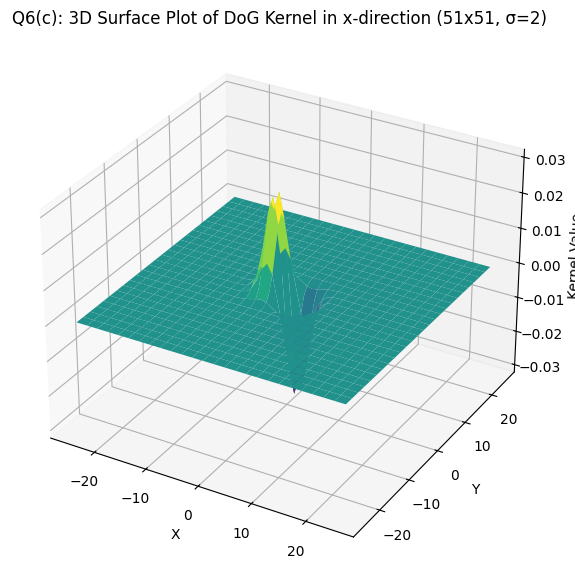

In [2]:
# -----------------------------------
# Q6(c) - 3D Surface Plot of 51x51 DoG Kernel
# -----------------------------------

gx_51, gy_51 = dog_kernels(51, sigma)

half = 51 // 2
X, Y = np.meshgrid(
    np.arange(-half, half + 1),
    np.arange(-half, half + 1)
)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, gx_51, cmap='viridis')

ax.set_title('Q6(c): 3D Surface Plot of DoG Kernel in x-direction (51x51, σ=2)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Kernel Value')

plt.show()

#### Q6(c): A 51×51 derivative-of-Gaussian kernel was visualized as a 3D surface. Unlike the Gaussian kernel, which has a single smooth peak, the derivative kernel contains positive and negative regions separated by a zero-crossing. This reflects its role in detecting intensity changes rather than smoothing.

### Q6(d) — Apply the derivative-of-Gaussian kernels to obtain horizontal and vertical gradients

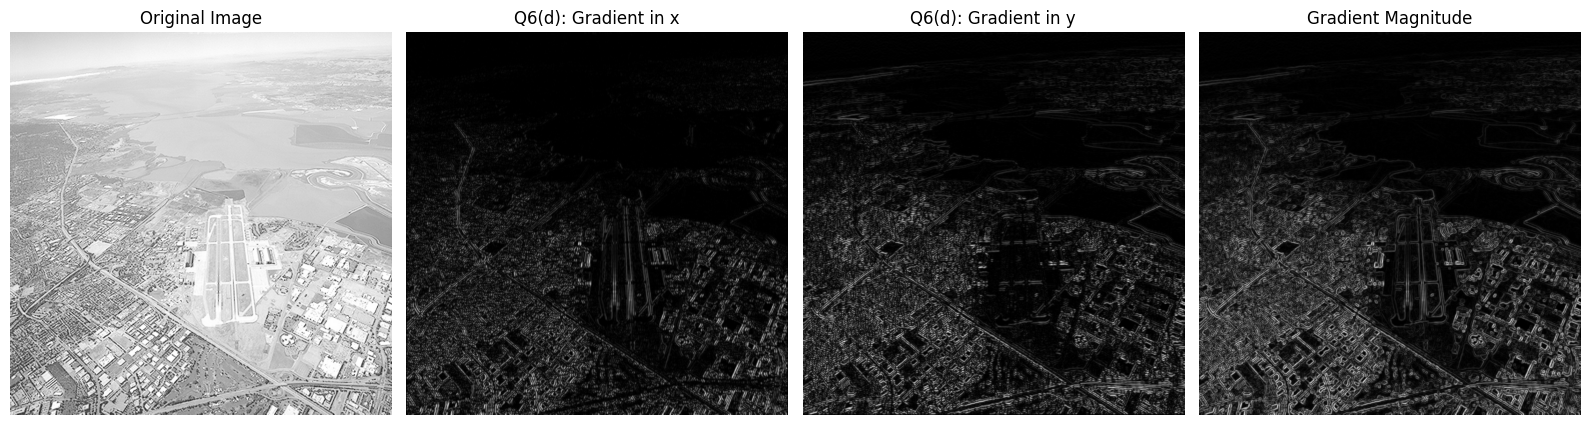

In [4]:
# -----------------------------------
# Load grayscale image
# -----------------------------------

img = cv.imread('runway.png', cv.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError("Image not found. Check file path.")

# -----------------------------------
# Manual convolution function
# -----------------------------------

def manual_convolution(image, kernel):
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2

    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='reflect')
    output = np.zeros_like(image, dtype=np.float64)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+kh, j:j+kw]
            output[i, j] = np.sum(region * kernel)

    return output

# Apply DoG kernels
grad_x = manual_convolution(img, gx_5x5)
grad_y = manual_convolution(img, gy_5x5)

# Magnitude of gradient
grad_mag = np.sqrt(grad_x**2 + grad_y**2)

# Normalize for display
grad_x_disp = cv.normalize(np.abs(grad_x), None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
grad_y_disp = cv.normalize(np.abs(grad_y), None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
grad_mag_disp = cv.normalize(grad_mag, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

# Display
plt.figure(figsize=(16,5))

plt.subplot(1,4,1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(grad_x_disp, cmap='gray')
plt.title('Q6(d): Gradient in x')
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(grad_y_disp, cmap='gray')
plt.title('Q6(d): Gradient in y')
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(grad_mag_disp, cmap='gray')
plt.title('Gradient Magnitude')
plt.axis('off')

plt.tight_layout()
plt.show()

#### Q6(d): The derivative-of-Gaussian kernels were applied to the grayscale image to obtain horizontal and vertical gradients. The x-direction result emphasized changes across columns, while the y-direction result emphasized changes across rows. The gradient magnitude image combined both responses and highlighted the main edges in the scene.

#### Q6(e) — Use OpenCV Sobel and compare the results

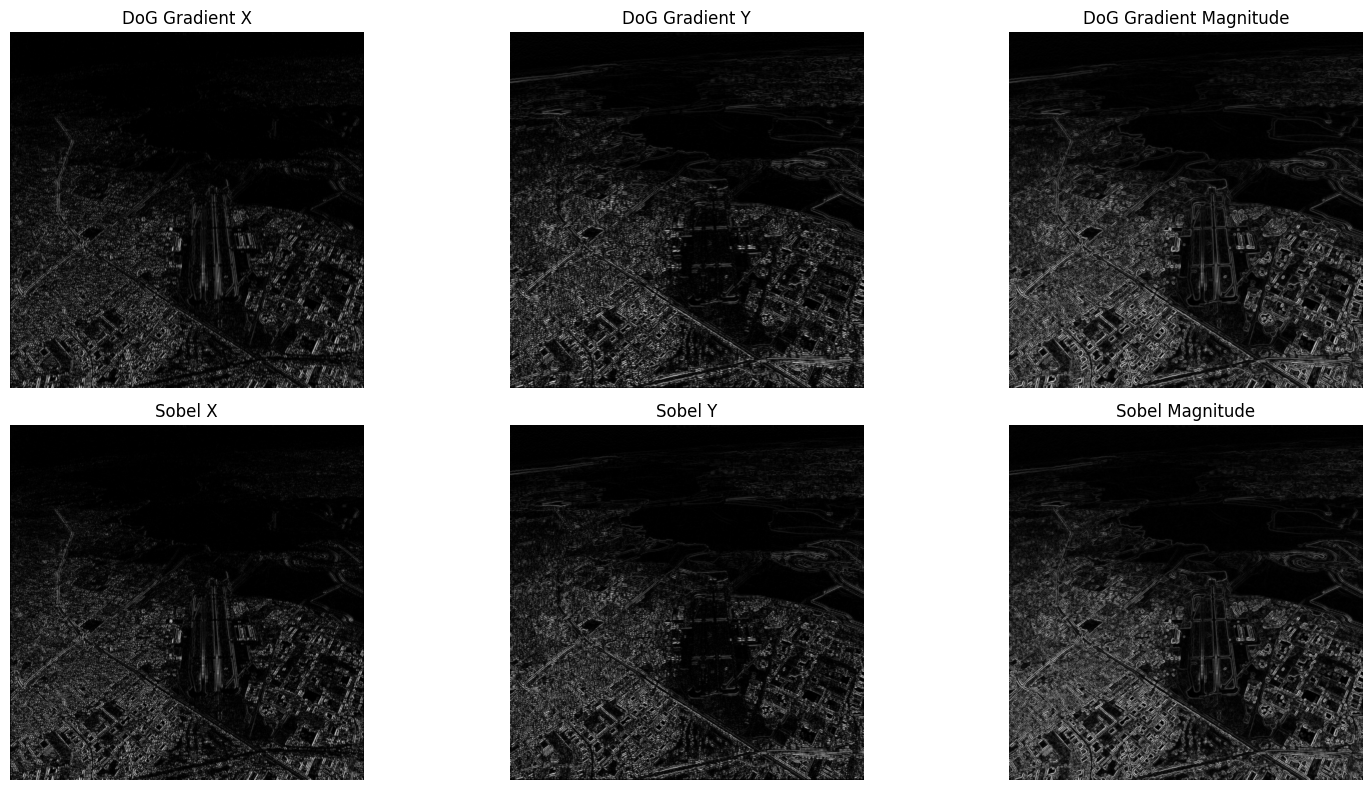

In [5]:
# -----------------------------------
# Q6(e) - Sobel Comparison
# -----------------------------------

sobel_x = cv.Sobel(img, cv.CV_64F, 1, 0, ksize=5)
sobel_y = cv.Sobel(img, cv.CV_64F, 0, 1, ksize=5)
sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)

# Normalize for display
sobel_x_disp = cv.normalize(np.abs(sobel_x), None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
sobel_y_disp = cv.normalize(np.abs(sobel_y), None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
sobel_mag_disp = cv.normalize(sobel_mag, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

# Display comparison
plt.figure(figsize=(16,8))

plt.subplot(2,3,1)
plt.imshow(grad_x_disp, cmap='gray')
plt.title('DoG Gradient X')
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(grad_y_disp, cmap='gray')
plt.title('DoG Gradient Y')
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(grad_mag_disp, cmap='gray')
plt.title('DoG Gradient Magnitude')
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(sobel_x_disp, cmap='gray')
plt.title('Sobel X')
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(sobel_y_disp, cmap='gray')
plt.title('Sobel Y')
plt.axis('off')

plt.subplot(2,3,6)
plt.imshow(sobel_mag_disp, cmap='gray')
plt.title('Sobel Magnitude')
plt.axis('off')

plt.tight_layout()
plt.show()

#### Q6(e): The image gradients were also computed using OpenCV’s Sobel operator. Both methods produced similar edge patterns, since both are based on first-order derivatives. However, the derivative-of-Gaussian result appeared slightly smoother because the Gaussian component performs smoothing before differentiation. In contrast, the Sobel result may appear slightly sharper or more discrete. Overall, both methods successfully highlighted the main edges of the image.